# Imports

In [1]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import requests
import seaborn as sns
import pandas as pd
import numpy as np
import io
import re

# this code is only included because we run on Deepnote and it doesn't have the execution counter like 
# Jupyter notebook does, and I used it for troubleshooting.
from IPython import get_ipython
print(f"Execution count: {get_ipython().execution_count}")

Execution count: 2


## Migration DataFrame (county_to_county_migration_df)

In [2]:
# This is the county to county migration data from the ACS Migration Flows dataset.
county_to_county_migration_df = pd.read_csv('data/county_to_county_US_2020.csv', dtype={'GEOID1': str, 'GEOID2':str, 'state':str, 'county':str})
county_to_county_migration_df.head(2)

,GEOID1,GEOID2,FULL1_NAME,FULL2_NAME,STATE1_NAME,STATE2_NAME,MOVEDIN,MOVEDOUT,MOVEDNET,POP1YR,POP1YRAGO,state,county
0,01001,01003,"Autauga County, Alabama","Baldwin County, Alabama",Alabama,Alabama,30.0,489.0,-459.0,54929.0,57775.0,01,001
1,01001,01005,"Autauga County, Alabama","Barbour County, Alabama",Alabama,Alabama,5.0,0.0,5.0,54929.0,57775.0,01,001


In [3]:
county_to_county_migration_df.shape

(406348, 13)

## County Health Rankings DataFrame (county_health_rankings_df)

In [4]:
# This code loads the Health Groups tab from the 2025 County Health Rankings Excel file
county_health_rankings_df = pd.read_excel('data/health_rankings_2025.xlsx', header=1, sheet_name = 'Health Groups', dtype={'FIPS': str})

# This renames some columns to be more descriptive
col_rename_dict = {'National Z-Score':'PHWB National Z-Score', 'Health Group':'PHWB Health Group', 'Health Group Range':'PHWB Health Group Range', 
                    'National Z-Score.1':'CC National Z-Score', 'Health Group.1':'CC Health Group', 'Health Group Range.1':'CC Health Group Range'}
county_health_rankings_df = county_health_rankings_df.rename(columns=col_rename_dict)
county_health_rankings_df.head(2)

,FIPS,State,County,Number of Counties Included in Health Groups,PHWB National Z-Score,PHWB Health Group,PHWB Health Group Range,CC National Z-Score,CC Health Group,CC Health Group Range
0,01000,Alabama,NaN,67,NaN,NaN,NaN,NaN,NaN,NaN
1,01001,Alabama,Autauga,67,0.040894,5.0,-0.05 to 0.27,-0.114428,5.0,-0.17 to 0.03


In [5]:
county_health_rankings_df.shape

(3210, 10)

In [6]:
county_health_rankings_df.columns

Index(['FIPS', 'State', 'County',
       'Number of Counties Included in Health Groups', 'PHWB National Z-Score',
       'PHWB Health Group', 'PHWB Health Group Range', 'CC National Z-Score',
       'CC Health Group', 'CC Health Group Range'],
      dtype='object')

## Merging the DataFrames (merged_df)

In [7]:
# This code merges the health data

merged_df = pd.merge(county_to_county_migration_df.rename(columns={'state':'statecode', 'county':'countycode', \
            'MOVEDNET':'Net_Migration'}), county_health_rankings_df, left_on=['GEOID1'], right_on=['FIPS'])
# print(merged_df.columns, len(merged_df.columns)) # uncommend to see columns and num_columns
merged_df.head(2)

,GEOID1,GEOID2,FULL1_NAME,FULL2_NAME,STATE1_NAME,STATE2_NAME,MOVEDIN,MOVEDOUT,Net_Migration,POP1YR,...,FIPS,State,County,Number of Counties Included in Health Groups,PHWB National Z-Score,PHWB Health Group,PHWB Health Group Range,CC National Z-Score,CC Health Group,CC Health Group Range
0,01001,01003,"Autauga County, Alabama","Baldwin County, Alabama",Alabama,Alabama,30.0,489.0,-459.0,54929.0,...,01001,Alabama,Autauga,67,0.040894,5.0,-0.05 to 0.27,-0.114428,5.0,-0.17 to 0.03
1,01001,01005,"Autauga County, Alabama","Barbour County, Alabama",Alabama,Alabama,5.0,0.0,5.0,54929.0,...,01001,Alabama,Autauga,67,0.040894,5.0,-0.05 to 0.27,-0.114428,5.0,-0.17 to 0.03


In [8]:
merged_df.shape

(401960, 23)

# Visualizing Migration compared to Public Health and Well-Being (phwb) and Community Score (cc)

## Create Health (phwb_df) and Community (cc_df) dataframes

In [9]:
# lists of cols I don't need
drop_list = ['GEOID2', 'FULL1_NAME', 'FULL2_NAME', 'STATE1_NAME', 'STATE2_NAME', 'statecode', 'countycode', 'FIPS', 'State', 'County', 'Number of Counties Included in Health Groups']
pop_cols = ['POP1YR', 'POP1YRAGO', 'MOVEDIN', 'MOVEDOUT']
cc_score_cols = ['CC National Z-Score', 'CC Health Group', 'CC Health Group Range',]
phwb_score_cols = ['PHWB National Z-Score', 'PHWB Health Group', 'PHWB Health Group Range']

In [10]:
# merged_df.columns # uncomment to see columns

In [11]:
# Create PHWB df for Sankey diagrams - this creates a lookup for each GEOID of its PHWB scores
phwb_df = merged_df.drop(columns= drop_list + pop_cols + cc_score_cols + ['Net_Migration'])
phwb_df = phwb_df.drop_duplicates().rename(columns={'GEOID1':'GEOID'})
# print(phwb_df.columns) # uncomment to see columns

# When I join the lookup back on the merged dataset, I now have the PHWB scores for the destination as well
phwb_sankey_df = pd.merge(merged_df, phwb_df, left_on=['GEOID2'], right_on=['GEOID'])
del phwb_df

# I drop columns othern than origin and destination PHWB groups, z-score groups, population, and migration
phwb_sankey_df = phwb_sankey_df.drop(columns=drop_list + cc_score_cols + ['GEOID1', 'GEOID', 'PHWB National Z-Score_x','PHWB National Z-Score_y',])
# print(phwb_sankey_df.columns) # uncomment to see columns

# now I group the population and migration figures to get the group-to-to-group figures for PHWB
phwb_sankey_df = phwb_sankey_df.groupby(by=['PHWB Health Group_x',
       'PHWB Health Group Range_x', 
       'PHWB Health Group_y',
       'PHWB Health Group Range_y'], as_index=False)[pop_cols + ['Net_Migration']].sum()
phwb_sankey_df.head(2)

,PHWB Health Group_x,PHWB Health Group Range_x,PHWB Health Group_y,PHWB Health Group Range_y,POP1YR,POP1YRAGO,MOVEDIN,MOVEDOUT,Net_Migration
0,1.0,-1.81 to -1.08,1.0,-1.81 to -1.08,2.578977e+09,2.560285e+09,531158.0,531158.0,0.0
1,1.0,-1.81 to -1.08,2.0,-1.07 to -0.71,4.030967e+09,4.002694e+09,732779.0,756263.0,-23484.0


In [12]:
# Create CC df for Sankey diagrams - this creates a lookup for each GEOID of its CC scores
cc_df = merged_df.drop(columns= drop_list + pop_cols + phwb_score_cols + ['Net_Migration'])
cc_df = cc_df.drop_duplicates().rename(columns={'GEOID1':'GEOID'})

# When I join the lookup back on the merged dataset, I now have the CC scores for the destination as well
cc_sankey_df = pd.merge(merged_df, cc_df, left_on=['GEOID2'], right_on=['GEOID'])
del cc_df 

# I drop columns othern than origin and destination CC groups, z-score groups, population, and migration
cc_sankey_df = cc_sankey_df.drop(columns=drop_list + phwb_score_cols + ['GEOID1', 'GEOID', 'CC National Z-Score_x','CC National Z-Score_y',])
# print(cc_sankey_df.columns) # uncomment to see columns

# now I group the population and migration figures to get the group-to-to-group figures for CC
cc_sankey_df = cc_sankey_df.groupby(by=['CC Health Group_x',
       'CC Health Group Range_x', 
       'CC Health Group_y',
       'CC Health Group Range_y'], as_index=False)[pop_cols + ['Net_Migration']].sum()
cc_sankey_df.head(2)

,CC Health Group_x,CC Health Group Range_x,CC Health Group_y,CC Health Group Range_y,POP1YR,POP1YRAGO,MOVEDIN,MOVEDOUT,Net_Migration
0,1.0,-1.61 to -0.81,1.0,-1.61 to -0.81,6.364301e+08,6.331337e+08,195828.0,195828.0,0.0
1,1.0,-1.61 to -0.81,2.0,-0.81 to -0.58,1.080752e+09,1.075316e+09,254598.0,266097.0,-11499.0


## Sankey 1 - Movement between groups

In [13]:
# This function allows us to plot a Sankey - from the source to the target group

def create_bilateral_sankey(df, source_col, target_col, value_col, title="Movement between Groups"):
    all_nodes = pd.concat([df[source_col], df[target_col]]).unique()
    n_groups = len(all_nodes)

    node_map = {name: i for i, name in enumerate(all_nodes)} # this prevents issues from 'str' format digits
    source_indices = df[source_col].map(node_map)
    target_indices = df[target_col].map(node_map)
    target_indices_offset = target_indices + n_groups
    
    # We're using Plotly Graph Objects' Sankey function to plot it.
    fig = go.Figure(data=[go.Sankey(
        node = dict(
            pad = 15,
            thickness = 20,
            line = dict(color = "black", width = 0.5),
            label = np.concatenate([all_nodes, all_nodes]),
            color = "blue"      
        ),
        # The "links" are the flows
        link = dict(
            source = source_indices,           # Origin County health groups
            target = target_indices_offset,    # Destination County health groups
            value = df[value_col]              # The volume of migration flow
        )
    )])

    fig.update_layout(title_text=title, font_size=10)
    
    return fig 

In [14]:
fig_phwb = create_bilateral_sankey(
    df=phwb_sankey_df,
    source_col='PHWB Health Group_x',
    target_col='PHWB Health Group_y',
    value_col='Net_Migration',  # or 'MOVEDIN'
    title="PHWB Health Group Movement"
)
fig_phwb.show()

There are some interesting takeaways. Group 4 has net negative migration with every other group - they lose population overall no matter that the destination group is. Group 10 is the opposite - they gain population from every group. 

In [15]:
fig_cc = create_bilateral_sankey(
    df=cc_sankey_df,
    source_col='CC Health Group_x',
    target_col='CC Health Group_y',
    value_col='Net_Migration', # or 'MOVEDIN'
    title="CC Health Group Movement"
)
fig_cc.show()

Similar, but every group gains from some groups overall and loses to others, unlike group 4 and 10 for PHWB.

## Sankey 2 - Delta Sankey
Here, I'm going to present the information as the *change* - the "delta" between origin and destination group. Therefore, all migration source will be represented as a single group, and there will be 19 destinations (-9 to +9). The intent of this part of the exploration is to see if it's easier to learn from.

In [16]:
def calculate_relative_y(val_col, sub_df, start_y, end_y, total_sub_vol):
    '''
    helper function for calculate_sankey_coords() which returns the relative y position for each delta group
    '''
    if total_sub_vol == 0: 
        return []

    cumsum = sub_df[val_col].cumsum()                   # find the cumulative sum for this group
    prev = cumsum.shift(1).fillna(0)                    # use shift(1) to find the start of each bar, with the first starting at 0
    center_vol = (prev + cumsum) / 2                    # calculate the center
    fraction = center_vol / total_sub_vol               # normalize to 0-1 within the sub_df
    y_pos = start_y + (fraction * (end_y - start_y))    # rescale the "fraction" to fit within the sub_df's start and end y
    
    return y_pos

def calculate_sankey_coords(agg, val_col):
    '''
    This function is designed to adjust the y-boundaries of the tails so that the visual density for positive 
    delta groups and the visual density for the negative delta groups are the same - that is to say, there are 
    no big gaps between the flows on one half (positive v negative aka top v bottom) as compared to the other.
    '''
    pos = agg[agg['Delta'] > 0]
    zero = agg[agg['Delta'] == 0]
    neg = agg[agg['Delta'] < 0]

    v_pos = pos[val_col].sum()
    v_zero = zero[val_col].sum()
    v_neg = neg[val_col].sum()
    v_total = v_pos + v_zero + v_neg
    
    # find positions for each delta category based on volume, with +0 locked in the middle and the positives and negatives around it
    y_pos = calculate_relative_y(val_col, pos, 0.0, 1 - (v_pos + v_zero)/(v_total), v_pos).tolist()
    y_zero = [0.5] if not zero.empty else []
    y_neg = calculate_relative_y(val_col, neg, 0.5, 0.5 + v_neg/v_total, v_neg).tolist()

    x_coords = [0.01] + [0.90] * len(agg)
    y_coords = [0.5] + y_pos + y_zero + y_neg

    return x_coords, y_coords

def plot_delta_sankey(df, source_col, target_col, val_col, title="Migration Delta"):
    """
    Creates a Delta Sankey (All Sources -> Change in Rank) with a straight line across to +0.
    """
    # 1. Process Data: Calculate Delta, Aggregate, and Sort (+9 to -9)
    # We use a copy to avoid modifying the original dataframe
    d = df.copy()
    d['Delta'] = pd.to_numeric(d[target_col]) - pd.to_numeric(d[source_col])
    agg = d.groupby('Delta')[val_col].sum().sort_index(ascending=False).reset_index()

    x_coords, y_coords = calculate_sankey_coords(agg, val_col)

    # 3. Define Visuals
    # Colors: Green (>0), Red (<0), Grey (0)
    colors = agg['Delta'].apply(lambda x: "rgba(50, 168, 82, 0.4)" if x > 0 else 
                                          "rgba(219, 64, 82, 0.4)" if x < 0 else 
                                          "rgba(200, 200, 200, 0.4)")
    labels = ["All Starting Groups"] + [f"{x:+.0f}" for x in agg['Delta']]

    # 4. Plot
    fig = go.Figure(go.Sankey(
        arrangement="snap",
        node=dict(
            pad=10, thickness=20, line=dict(color="black", width=0.5),
            label=labels, color="blue", x=x_coords, y=y_coords

        ),
        link=dict(
            source=[0] * len(agg),         # All flows start at index 0
            target=list(range(1, len(agg)+1)), # Targets are 1..N
            value=agg[val_col],
            color=colors
        )
    ))
    
    fig.update_layout(title=title, font_size=10, width = 900, height=600)
    return fig


In [17]:
# calling the function for CC
fig = plot_delta_sankey(
    df=cc_sankey_df, 
    source_col='CC Health Group_x', 
    target_col='CC Health Group_y', 
    val_col='MOVEDIN',
    title="CC Movement"
)
fig.show()

In [18]:
# now for PHWB
fig = plot_delta_sankey(
    df=phwb_sankey_df, 
    source_col='PHWB Health Group_x', 
    target_col='PHWB Health Group_y', 
    val_col='MOVEDIN',
    title="PHWB Movement"
)
fig.show()

That looks an awful lot like I've just done a lot of work to create a complex histogram. Let's see if I can learn anything by making it a butterfly - in to the middle, out to the right.

## Sankey 3 - Butterfly
I want to see if modeling both the in and outflows at once would lead to any insight.

In [19]:
def plot_butterfly_sankey(df, source_col, target_col, in_col, out_col, title="Migration Butterfly"):
    # 1. Data Prep
    d = df.copy()
    d['Delta'] = pd.to_numeric(d[target_col]) - pd.to_numeric(d[source_col])
    agg = d.groupby('Delta')[[in_col, out_col]].sum().sort_index(ascending=False).reset_index()
    n_groups = len(agg)

    y_right = calculate_sankey_coords(agg, in_col)[1][1:] # slice to look at only the y_coords, and skip the first one which is for the center block
    y_left = calculate_sankey_coords(agg, out_col)[1][1:] # slice to look at only the y_coords, and skip the first one which is for the center block

    labels = ["All Starting Groups"] + \
             [f"{x:+.0f}" for x in agg['Delta']] + \
             [f"{x:+.0f}" for x in agg['Delta']]
    
    x_coords = [0.5] + [0.99] * n_groups + [0.01] * n_groups
    y_coords = [0.5] + y_right + y_left
    
    # Colors (Green/Red/Grey)
    color_map = agg['Delta'].apply(lambda x: "rgba(50, 168, 82, 0.4)" if x > 0 else 
                                             "rgba(219, 64, 82, 0.4)" if x < 0 else 
                                             "rgba(200, 200, 200, 0.4)").tolist()

    # 4. Construct Links
    # Link Set 1: Left Nodes -> Center (Weighted by MOVEDOUT)
    # Source Indices: 21 to (20+N) -> range(1+n_groups, 1+2*n_groups)
    # Target Index: 0
    link_src_1 = list(range(1 + n_groups, 1 + 2 * n_groups))
    link_tgt_1 = [0] * n_groups
    link_val_1 = agg[out_col]

    # Link Set 2: Center -> Right Nodes (Weighted by MOVEDIN)
    # Source Index: 0
    # Target Indices: 1 to N -> range(1, 1+n_groups)
    link_src_2 = [0] * n_groups
    link_tgt_2 = list(range(1, 1 + n_groups))
    link_val_2 = agg[in_col]

    # Combine Links
    final_src = link_src_1 + link_src_2
    final_tgt = link_tgt_1 + link_tgt_2
    final_val = pd.concat([link_val_1, link_val_2])
    final_colors = color_map + color_map # Use delta colors for flow

    # 5. Plot
    fig = go.Figure(go.Sankey(
        arrangement="snap",
        node=dict(
            pad=10, thickness=20, line=dict(color="black", width=0.5),
            label=labels, 
            color='Blue',
            x=x_coords, 
            y=y_coords
        ),
        link=dict(
            source=final_src,
            target=final_tgt,
            value=final_val,
            color=final_colors
        )
    ))
    
    fig.update_layout(title=title, font_size=10, width=1000, height=600)
    return fig

In [20]:
fig = plot_butterfly_sankey(
    df=cc_sankey_df, 
    source_col='CC Health Group_x', 
    target_col='CC Health Group_y', 
    in_col='MOVEDIN',
    out_col='MOVEDOUT', 
    title="CC Movement (In vs Out)"
)
fig.show()

In [21]:
fig = plot_butterfly_sankey(
    df=phwb_sankey_df, 
    source_col='PHWB Health Group_x', 
    target_col='PHWB Health Group_y', 
    in_col='MOVEDIN',
    out_col='MOVEDOUT', 
    title="PHWB Movement (In vs Out)"
)
fig.show()

I'm not really seeing a lot here. Maybe I *should* just try a histogram.

## Simple Histogram

In [22]:
def plot_movement_histogram(df, source_col, target_col, value_col, title="missingtitle", ax=None):
    '''
    By returning the axis instead of a standalone figure, we allow the user to create subplots and use
    this function to create the plots within each subplot. 
    '''

    # 1. Process Data
    d = df.copy()
    d['Delta'] = pd.to_numeric(d[target_col]) - pd.to_numeric(d[source_col])
    df_agg = d.groupby('Delta')[value_col].sum().sort_index().reset_index()

    # 2. Create Figure and Axis
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    
    # 3. Plot
    colors = df_agg['Delta'].apply(lambda x: 'green' if x > 0 else 'red' if x < 0 else 'grey')
    ax.bar(df_agg['Delta'], df_agg[value_col], color=colors, alpha=0.6, edgecolor='black')

    # 4. Format
    ax.set_title(title)
    ax.set_xlabel('Change in Rank (Delta)')
    ax.set_ylabel('Volume')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # 5. Signed Ticks (e.g., +1, +0, -1)
    ax.set_xticks(df_agg['Delta'])
    ax.set_xticklabels([f"{x:+.0f}" for x in df_agg['Delta']])

    # 6. Return the axis object
    return ax

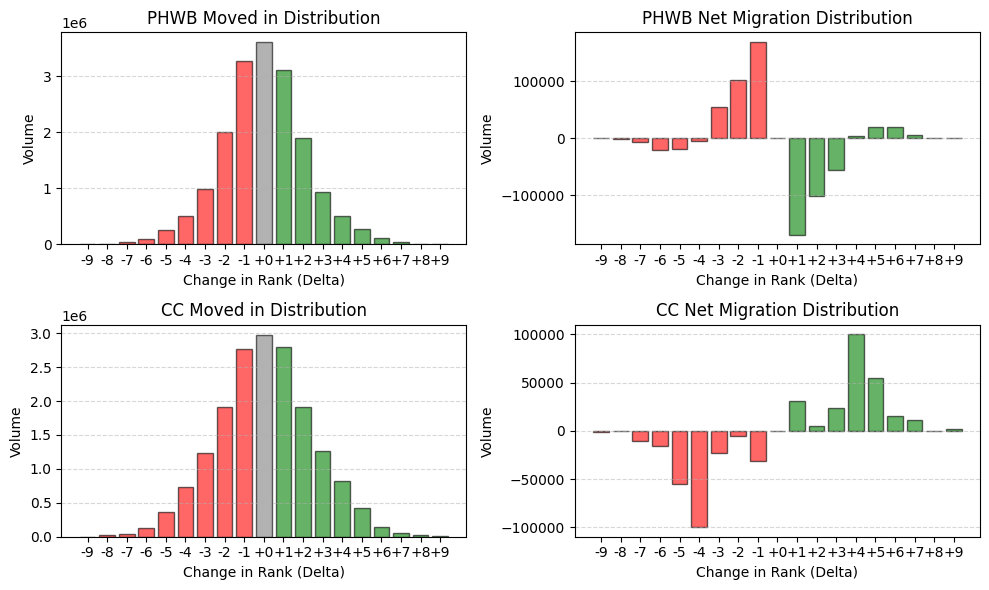

In [23]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6)) # a 2x2 subplot area

plot_movement_histogram(
    df=phwb_sankey_df,
    source_col='PHWB Health Group_x',
    target_col='PHWB Health Group_y',
    value_col='MOVEDIN',
    title='PHWB Moved in Distribution',
    ax=axes[0,0] # top left axis
)

plot_movement_histogram(
    df=phwb_sankey_df,
    source_col='PHWB Health Group_x',
    target_col='PHWB Health Group_y',
    value_col='Net_Migration',
    title='PHWB Net Migration Distribution',
    ax=axes[0,1] # top right axis
)

plot_movement_histogram(
    df=cc_sankey_df,
    source_col='CC Health Group_x',
    target_col='CC Health Group_y',
    value_col='MOVEDIN',
    title='CC Moved in Distribution',
    ax=axes[1,0] # bottom left
)

plot_movement_histogram(
    df=cc_sankey_df,
    source_col='CC Health Group_x',
    target_col='CC Health Group_y',
    value_col='Net_Migration',
    title='CC Net Migration Distribution',
    ax=axes[1,1] # bottom right
)

plt.tight_layout()
plt.show()

Visually this seems really balanced for both PHWB and CC - the charts on the right make it look imbalanced, but if you look at the scale, the differences are relatively minor.

### Statistical analysis 
I wondered how skewed this data was from a statistical perspective.

In [24]:
import pandas as pd
import numpy as np

def analyze_migration_stats(df, name, source_col, target_col, cols_to_analyze=['MOVEDIN']):
    """
    Calculates weighted mean and skewness for specified columns, and returns a breakdown of positive, 
    negative, and neutral moves.
    """
    # 1. Prepare Data
    d = df.copy()
    
    d['Delta'] = pd.to_numeric(d[target_col], errors='coerce') - pd.to_numeric(d[source_col], errors='coerce')
    
    results = []

    # 2. Calculate Weighted Stats for each column
    for col in cols_to_analyze:
        values = d['Delta'].values
        weights = d[col].values
        
        # Calculate Weighted Mean
        # formula: sum(w * x) / sum(w)
        total_weight = np.sum(weights)
    
        w_mean = np.average(values, weights=weights)
        
        # Calculate Weighted Skewness
        # formula: sum(w * (x - mean)^3) / (sum(w) * std^3)
        # First, weighted variance/std
        variance = np.average((values - w_mean)**2, weights=weights)
        std = np.sqrt(variance)
        
        if std == 0:
            w_skew = 0.0 # No variance means no skew
        else:
            w_skew = np.average(((values - w_mean) / std)**3, weights=weights)
        
        # Calculate Counts/Percentages Breakdown (Positive/Negative/No Change)
        # This is based on the specific column's volume
        pos_vol = d[d['Delta'] > 0][col].sum()
        neg_vol = d[d['Delta'] < 0][col].sum()
        zero_vol = d[d['Delta'] == 0][col].sum()
        
        # Percentages
        pos_pct = (pos_vol / total_weight) * 100 if total_weight else 0
        neg_pct = (neg_vol / total_weight) * 100 if total_weight else 0
        zero_pct = (zero_vol / total_weight) * 100 if total_weight else 0

        results.append({
            'Name': name,
            'Metric': col,
            'Total Volume': total_weight,
            'Weighted Mean': w_mean,
            'Weighted Skewness': w_skew,
            'Positive Moves (Vol)': pos_vol,
            'Positive Moves (%)': pos_pct,
            'Negative Moves (Vol)': neg_vol,
            'Negative Moves (%)': neg_pct,
            'No Change (Vol)': zero_vol,
            'No Change (%)': zero_pct
        })

    # 3. Create Result DataFrame
    results_df = pd.DataFrame(results).set_index('Name')
    
    return results_df.T

In [25]:
phwb_stats_df = analyze_migration_stats(
    df=phwb_sankey_df,
    name = 'Public Health and Wellbeing',
    source_col='PHWB Health Group_x',
    target_col='PHWB Health Group_y',
    cols_to_analyze=['MOVEDIN']
)

# --- Example Usage ---
cc_stats_df = analyze_migration_stats(
    df=cc_sankey_df,
    name = 'Community Conditions',
    source_col='CC Health Group_x',
    target_col='CC Health Group_y',
    cols_to_analyze=['MOVEDIN']
)
stats_df = cc_stats_df.join(phwb_stats_df)
stats_df

Name,Community Conditions,Public Health and Wellbeing
Metric,MOVEDIN,MOVEDIN
Total Volume,17607952.0,17607952.0
Weighted Mean,0.055028,-0.014298
Weighted Skewness,0.019002,0.062096
Positive Moves (Vol),7437689.0,6865130.0
Positive Moves (%),42.240512,38.988805
Negative Moves (Vol),7195608.0,7139473.0
Negative Moves (%),40.865673,40.546868
No Change (Vol),2974655.0,3603349.0
No Change (%),16.893816,20.464328


Remarkably balanced! 





# Aggregating additional datapoints

## Bring in health_df

In [26]:
from functions import get_county_health_data

In [27]:
health_df = get_county_health_data()

In [28]:
health_df.shape

(3089, 10)

## Merge Migration (county_to_county_migration_df) with (health_df)

In [29]:
county_to_county_migration_df.head(2)

,GEOID1,GEOID2,FULL1_NAME,FULL2_NAME,STATE1_NAME,STATE2_NAME,MOVEDIN,MOVEDOUT,MOVEDNET,POP1YR,POP1YRAGO,state,county
0,01001,01003,"Autauga County, Alabama","Baldwin County, Alabama",Alabama,Alabama,30.0,489.0,-459.0,54929.0,57775.0,01,001
1,01001,01005,"Autauga County, Alabama","Barbour County, Alabama",Alabama,Alabama,5.0,0.0,5.0,54929.0,57775.0,01,001


In [30]:
county_to_county_migration_df.shape

(406348, 13)

In [31]:
# aggregate by origin county
migration_agg = county_to_county_migration_df.groupby('GEOID1').agg({
    'MOVEDIN': 'sum',
    'MOVEDOUT': 'sum', 
    'MOVEDNET': 'sum',      # Total people gained/lost
    'POP1YR': 'mean',       # Population (should be constant for GEOID1, mean works)
    'POP1YRAGO': 'mean',    # Different than just pop1yr - movednet because people are born and later die
    'STATE1_NAME': 'first', # Keep state name
    'FULL1_NAME': 'first'   # Keep county name
}).reset_index()

# Normalize to net migration per 1,000 residents 
migration_agg['Net_Migration_Rate'] = (migration_agg['MOVEDNET'] / migration_agg['POP1YR']) * 1000
migration_agg['In_Migration_Rate'] = (migration_agg['MOVEDIN'] / migration_agg['POP1YR']) * 1000
migration_agg['Out_Migration_Rate'] = (migration_agg['MOVEDOUT'] / migration_agg['POP1YR']) * 1000

# Ensure GEOID1 is a 5-digit string with leading zeros (Shay did this in her notebook too)
migration_agg['FIPS'] = migration_agg['GEOID1'].astype(str).str.zfill(5)

# Merge
df_master = pd.merge(migration_agg, health_df, on='FIPS', how='left')

In [32]:
df_master.shape

(3221, 21)

In [33]:
df_master.head(2)

,GEOID1,MOVEDIN,MOVEDOUT,MOVEDNET,POP1YR,POP1YRAGO,STATE1_NAME,FULL1_NAME,Net_Migration_Rate,In_Migration_Rate,...,FIPS,State,County,Number of Counties Included in Health Groups,Health_Z_Score,Health Group,Health Group Range,Community_Z_Score,Health Group.1,Health Group Range.1
0,01001,3375.0,6501.0,-3126.0,54929.0,57775.0,Alabama,"Autauga County, Alabama",-56.909829,61.442954,...,01001,Alabama,Autauga,67.0,-0.040894,5.0,-0.05 to 0.27,0.114428,5.0,-0.17 to 0.03
1,01003,10770.0,8779.0,1991.0,216518.0,213875.0,Alabama,"Baldwin County, Alabama",9.195540,49.741823,...,01003,Alabama,Baldwin,67.0,0.309818,4.0,-0.38 to -0.06,0.386812,3.0,-0.58 to -0.37


## Now get the CHD Metrics file merged

In [34]:
## code for creating this file is in the '2. Ingesting and Cleaning Data' notebook
chd_metrics = pd.read_csv('data/cleaned_chd_metrics_2022.csv', index_col = 0, dtype={'FIPS':str})

In [35]:
chd_metrics.shape

(3142, 80)

In [36]:
df_master = pd.merge(df_master, chd_metrics, on='FIPS', how='left')

In [37]:
df_master.shape

(3221, 100)

# Future Step - further data exploration 
I see that the datasets are of different lengths, so I'm going to note that here. I would look into it, but I don't realistically have time. Instead, I'm going to redo the joins with inner-joins, just so I can move forward with the correlation and regression analysis. If I had time, I would analyze the data, understand why it is the way it is, try to determine if there's any bias that would be introduced by including it or excluding it, and so forth. 






# Correlation Analysis

## Data Prep

In [38]:
 df_master = pd.merge(migration_agg, health_df, on='FIPS', how='inner')
 df_master.shape

(3080, 21)

In [39]:
df_master = pd.merge(df_master, chd_metrics, on='FIPS', how='inner')
df_master.shape

(3080, 100)

In [40]:
# Now we have some duplicative columns to drop. 
drop_cols = ['STATE1_NAME', 'FULL1_NAME', 'Number of Counties Included in Health Groups', 'FIPS', 'statecode','countycode','fipscode', 'state','county']
df_master = df_master.drop(columns = drop_cols)

In [41]:
# rename some columns to be more legible
rename_col_key = {'Health Group.1' : 'Community Score Group', 'Health Group Range.1' : 'Community Score Range'}
df_master = df_master.rename(columns=rename_col_key)
df_master.head(2)

,GEOID1,MOVEDIN,MOVEDOUT,MOVEDNET,POP1YR,POP1YRAGO,Net_Migration_Rate,In_Migration_Rate,Out_Migration_Rate,State,...,above_65_proportion,race_black_proportion,race_native_proportion,race_asian_proportion,race_hawaiian_pacific_islander_proportion,race_hispanic_proportion,race_caucasian_proportion,not_proficient_in_english_proportion,female_proportion,rural_proportion
0,01001,3375.0,6501.0,-3126.0,54929.0,57775.0,-56.909829,61.442954,118.352783,Alabama,...,0.161760,0.203188,0.004738,0.011702,0.001086,0.031009,0.731659,0.006927,0.515077,0.420022
1,01003,10770.0,8779.0,1991.0,216518.0,213875.0,9.195540,49.741823,40.546283,Alabama,...,0.215821,0.084789,0.007798,0.011030,0.000663,0.046339,0.833083,0.007721,0.515891,0.422791


In [42]:
# now add region
regions_map = {'Connecticut': 'Northeast', 'Maine': 'Northeast', 'Massachusetts': 'Northeast', 'New Hampshire': 'Northeast', 'Rhode Island': 'Northeast', 
 'Vermont': 'Northeast', 'New Jersey': 'Northeast', 'New York': 'Northeast', 'Pennsylvania': 'Northeast',
 'Illinois': 'Midwest', 'Indiana': 'Midwest', 'Michigan': 'Midwest', 'Ohio': 'Midwest', 'Wisconsin': 'Midwest', 'Iowa': 'Midwest', 'Kansas': 'Midwest',
 'Minnesota': 'Midwest', 'Missouri': 'Midwest', 'Nebraska': 'Midwest', 'North Dakota': 'Midwest', 'South Dakota': 'Midwest',
 'Delaware': 'South', 'Florida': 'South', 'Georgia': 'South', 'Maryland': 'South', 'North Carolina': 'South', 'South Carolina': 'South', 'Virginia': 'South',
 'District of Columbia': 'South', 'West Virginia': 'South', 'Alabama': 'South', 'Kentucky': 'South', 'Mississippi': 'South', 
 'Tennessee': 'South', 'Arkansas': 'South', 'Louisiana': 'South', 'Oklahoma': 'South', 'Texas': 'South',
 'Arizona': 'West', 'Colorado': 'West', 'Idaho': 'West', 'Montana': 'West', 'Nevada': 'West', 'New Mexico': 'West', 'Utah': 'West',
 'Wyoming': 'West', 'Alaska': 'West', 'California': 'West',  'Hawaii': 'West', 'Oregon': 'West', 'Washington': 'West'}

df_master['Region'] = df_master['State'].map(regions_map)

In [43]:
# and create population categories
df_master['Pop_Category'] = pd.qcut(df_master['POP1YR'], q=4, labels=['Small', 'Medium', 'Large', 'Very Large'])

In [44]:
# Let's rearrange the columns for readability
new_col_order = ['GEOID1', 'State', 'County', 'Region', 'Pop_Category', 'POP1YR', 'POP1YRAGO', 
       'MOVEDIN', 'In_Migration_Rate', 'MOVEDOUT', 'Out_Migration_Rate', 'MOVEDNET', 'Net_Migration_Rate',  
       'Health_Z_Score', 'Health Group', 'Health Group Range', 'Community_Z_Score', 'Community Score Group', 'Community Score Range',
       'premature_death_years_lost_per_100k', 'adults_poor_or_fair_health_proportion', 'poor_physical_health_days_in_last_30_days_count_per_person',
       'poor_mental_health_days_in_last_30_days_count_per_person', 'food_environment_index', 'adults_physically_inactive_proportion',
       'people_with_access_to_exercise_opportunities_proportion', 'primary_care_physicians_density', 'mental_health_providers_density',
       'membership_associations_per_10k', 'air_pollution_particulate_matter_average_count', 'driving_alone_to_work_proportion_of_workforce',
       'driving_alone_on_long_commute_proportion_of_workforce', 'adults_frequent_poor_physical_health_proportion', 'adults_frequent_poor_mental_health_proportion',
       'food_insecurity_proportion', 'limited_access_to_healthy_food_proportion', 'childcare_costs_to_median_income_ratio', 'traffic_volume_count_per_roadway_meter',
       'children_in_poverty_proportion', 'income_inequality_ratio', 'children_in_single_parent_households_proportion', 
       'households_with_one_or_more_severe_housing_problem_proportion', 'median_household_income', 'owner_occupied_housing_units_proportion',
       'households_severe_housing_costs_proportion', '25_and_over_high_school_diploma_proportion', '25_to_44_some_college_completed_proportion', 'population_count',
       'below_18_proportion', 'above_65_proportion', 'race_black_proportion', 'race_native_proportion', 'race_asian_proportion', 'race_hawaiian_pacific_islander_proportion',
       'race_hispanic_proportion', 'race_caucasian_proportion', 'not_proficient_in_english_proportion', 'female_proportion', 'rural_proportion'
    ] + ['low_birthweight_proportion', 'adult_smoking_proportion', 'adult_obesity_proportion', 'adult_excessive_drinking_proportion', 
        'alcohol_related_deaths_proportion_of_driving_deaths', 'newly_diagnosed_chlamydia_count_per_100k', 'teen_births_count_per_100k', 
        'dentists_density', 'preventable_hospital_stays_count_per_100k', 'mammography_screening_proportion_of_female_medicare_65_to_74', 
        'flu_vax_proportion', 'violent_crime_count_per_100k', 'deaths_from_injury_count_per_100k', 'drinking_water_violations_indicator',
        'life_expectancy_years', 'premature_mortality_count_per_100k', 'adult_diabetes_proportion', 'adult_hiv_proportion', 
        'motor_vehicle_crash_deaths_count_per_100k', 'adults_without_health_insurance_proportion', 'children_without_health_insurance_proportion',
        'school_segregation_index', 'women_to_mens_pay_ratio', 'children_eligible_for_free_or_reduced_price_lunch_proportion',
        'residential_segregation_index', 'childcare_centers_per_1k', 'households_with_broadband_access_proportion',
        'third_grader_average_english_grade_level_performance', 'third_grader_average_math_grade_level_performance',
        'school_district_funding_above_target_spend_dollars', 'adults_insufficient_sleep_proportion', 'other_primary_care_providers_density',
        'under_65_no_health_insurance_proportion', 'over_15_unemployed_seeking_work_proportion'
    ]

df_master = df_master[new_col_order]
df_master.shape

(3080, 93)

## Correlation Analysis

### By population quartile

In [45]:
results = []

# Iterate through unique categories
for category in df_master['Pop_Category'].unique():
    subset = df_master[df_master['Pop_Category'] == category]

    # Calculate correlation using default of pearson r
    hncorr = subset['Health_Z_Score'].corr(subset['Net_Migration_Rate'])
    cncorr = subset['Community_Z_Score'].corr(subset['Net_Migration_Rate'])
    hicorr = subset['Health_Z_Score'].corr(subset['In_Migration_Rate'])
    cicorr = subset['Community_Z_Score'].corr(subset['In_Migration_Rate'])
    hocorr = subset['Health_Z_Score'].corr(subset['Out_Migration_Rate'])
    cocorr = subset['Community_Z_Score'].corr(subset['Out_Migration_Rate'])
    results.append({'Category': category, 'Health Net Migration Correlation': hncorr, 'Community Net Migration Correlation': cncorr,
                        'Health In Migration Correlation': hicorr, 'Community In Migration Correlation': cicorr,
                        'Health Out Migration Correlation': hocorr, 'Community Out Migration Correlation': cocorr,
                    })

pd.DataFrame(results)

,Category,Health Net Migration Correlation,Community Net Migration Correlation,Health In Migration Correlation,Community In Migration Correlation,Health Out Migration Correlation,Community Out Migration Correlation
0,Large,0.130306,0.059986,0.253193,0.209042,0.206063,0.219871
1,Very Large,0.045122,0.076312,0.150731,0.264726,0.159258,0.282245
2,Medium,0.019811,0.002678,0.158623,0.157120,0.164943,0.182821
3,Small,-0.001420,-0.058512,0.049582,-0.002074,0.039180,0.062053


Nothing is more than weakly correlated here. 

### Heatmap of numeric values

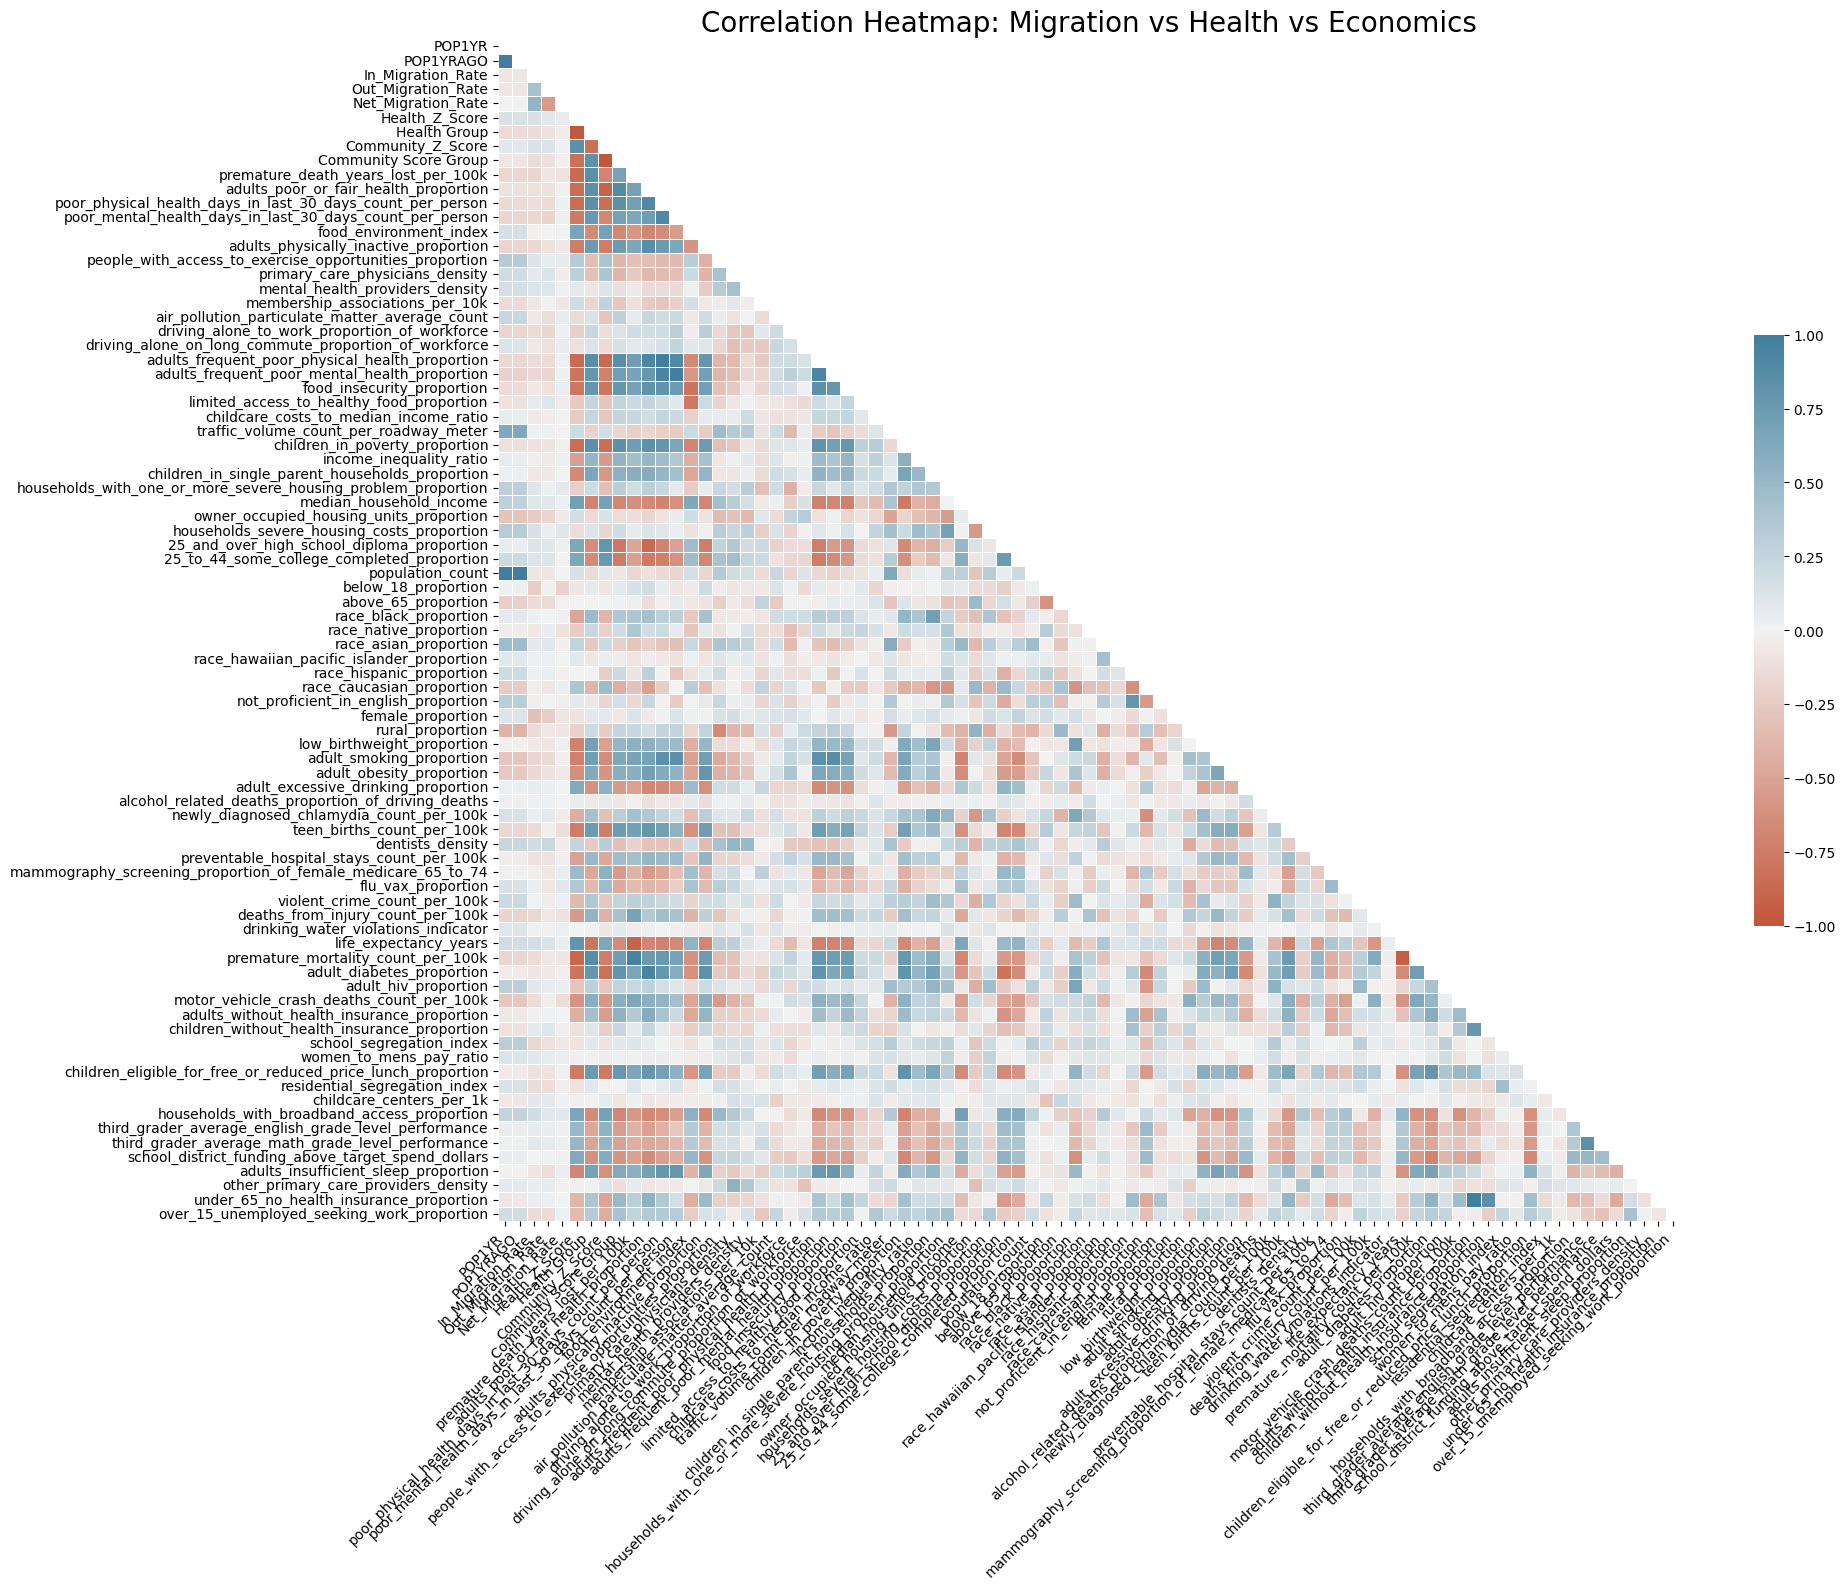

In [46]:
# copy only the numeric values
numeric_df = df_master.select_dtypes(include=[np.number])

# 2. Drop ID columns that might be numeric (like FIPS if it wasn't converted to string)
cols_to_drop = ['FIPS', 'GEOID1', 'MOVEDNET', 'MOVEDIN', 'MOVEDOUT'] 
numeric_df = numeric_df.drop(columns=[c for c in cols_to_drop if c in numeric_df.columns], errors='ignore')

# 3. Calculate Correlation Matrix
corr_matrix = numeric_df.corr()

# 4. Create the Heatmap
plt.figure(figsize=(20, 16)) # Large size for readability, which may be a moot point with so many variables

# Mask upper triangle (optional, makes it cleaner)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Diverging color map (Red = Negative, Blue = Positive)
cmap = sns.diverging_palette(20, 230, as_cmap=True)

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap=cmap, 
    center=0,
    vmax=1, 
    vmin=-1,
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .5}
)

plt.title('Correlation Heatmap: Migration vs Health vs Economics', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

There are a lot of things here to see, but it's challenging to see them. For one, ```children_in_poverty_proportion``` is highly negatively correlated with ```Health_Z_Score``` - the higher the proportion of children in poverty, the lower the Z score (same for ```Community_Z_Score```), which makes intuitive sense. Very high positive correlations between ```POP1YR```, ```POP1YRAGO```,and ```population_count``` also make complete sense. Regardless, this isn't an effective way to view these. Let's look at the numbers for just a select few.

### Correlations for Migration Rates

Let's focus in on the highest positive and negative correlations with the migration rates to see if there's anything we can find here. 

#### Net Migration Rate

In [47]:
corr_matrix['Net_Migration_Rate'].sort_values(ascending=False).head(5)

Net_Migration_Rate                             1.000000
In_Migration_Rate                              0.528827
households_severe_housing_costs_proportion     0.106792
flu_vax_proportion                             0.092166
households_with_broadband_access_proportion    0.082215
Name: Net_Migration_Rate, dtype: float64

In [48]:
corr_matrix['Net_Migration_Rate'].sort_values(ascending=False).tail(5)

deaths_from_injury_count_per_100k           -0.096323
teen_births_count_per_100k                  -0.117623
motor_vehicle_crash_deaths_count_per_100k   -0.125750
below_18_proportion                         -0.200637
Out_Migration_Rate                          -0.550716
Name: Net_Migration_Rate, dtype: float64

Look at the ```Net_Migration_Rate``` row / column ... almost no correlation with anything other than having moderate correlation with the other migration rates. The strongest correlation is with ```below_18_proportion```, which has a weak negative correlation of -0.20, and the highest positive is ```households_severe_housing_costs_proportion``` which has a *very* weak correlation of 0.107.

#### In Migration Rate

In [49]:
corr_matrix['In_Migration_Rate'].sort_values(ascending=False).head(5)

In_Migration_Rate                              1.000000
Net_Migration_Rate                             0.528827
Out_Migration_Rate                             0.417195
dentists_density                               0.187617
households_with_broadband_access_proportion    0.182622
Name: In_Migration_Rate, dtype: float64

In [50]:
corr_matrix['In_Migration_Rate'].sort_values(ascending=False).tail(5)

premature_death_years_lost_per_100k       -0.174599
adult_smoking_proportion                  -0.175640
below_18_proportion                       -0.228618
owner_occupied_housing_units_proportion   -0.238593
female_proportion                         -0.324500
Name: In_Migration_Rate, dtype: float64

```In_Migration_Rate``` is moderately positively correlated with ```Net_``` and ```Out_``` migration rates ... and nothing else. There's a weak positive correlation with ```dentists_density```.

It has a weak negative correlation with three variables - ```female_proportion```, ```owner_occupied_housing_units_proportion```, and ```below_18_proportion```.

It would be interesting to look into what variables ```female_proportion``` correlates with itself, to give us clues as to why having a higher female proportion would reduce the inward migration rate. Maybe it's indicative of a poor labor market that the men already moved out of. 

```below_18_proportion``` is also negatively correlated with inward migration - perhaps because as people get over 18, they move out, plus the population would be growing via birthrate. 

```owner_occupied_housing_units_proportion``` is also weakly negatively correlated with inward migration ... likely as it indicates less rental housing which is easier to move into. 




#### Out Migration Rate

In [51]:
corr_matrix['Out_Migration_Rate'].sort_values(ascending=False).head(5)

Out_Migration_Rate                 1.000000
In_Migration_Rate                  0.417195
dentists_density                   0.222731
life_expectancy_years              0.126098
primary_care_physicians_density    0.123971
Name: Out_Migration_Rate, dtype: float64

In [52]:
corr_matrix['Out_Migration_Rate'].sort_values(ascending=False).tail(7)

adult_smoking_proportion                                   -0.149825
driving_alone_to_work_proportion_of_workforce              -0.172482
owner_occupied_housing_units_proportion                    -0.176486
adults_frequent_poor_mental_health_proportion              -0.180069
poor_mental_health_days_in_last_30_days_count_per_person   -0.195291
female_proportion                                          -0.231592
Net_Migration_Rate                                         -0.550716
Name: Out_Migration_Rate, dtype: float64

Nothing (outside of the other migration rates) is even moderately correlated with outward migration. ```female_proportion``` shows up again here, again weakly negatively correlated.  Interestingly, ```dentists_density``` shows up here again, weakly positively correlated with out migration as well as in migration.







### Correlations for Z-Scores

#### Health Z Score

In [53]:
corr_matrix['Health_Z_Score'].sort_values(ascending=False).head(15)

Health_Z_Score                                                  1.000000
Community_Z_Score                                               0.829350
life_expectancy_years                                           0.802493
median_household_income                                         0.708189
food_environment_index                                          0.669296
households_with_broadband_access_proportion                     0.656068
25_to_44_some_college_completed_proportion                      0.643130
25_and_over_high_school_diploma_proportion                      0.635487
school_district_funding_above_target_spend_dollars              0.623175
adult_excessive_drinking_proportion                             0.623128
third_grader_average_math_grade_level_performance               0.506306
third_grader_average_english_grade_level_performance            0.487013
mammography_screening_proportion_of_female_medicare_65_to_74    0.472798
race_caucasian_proportion                          

In [54]:
corr_matrix['Health_Z_Score'].sort_values(ascending=False).tail(15)

adults_physically_inactive_proportion                          -0.746590
teen_births_count_per_100k                                     -0.749976
children_eligible_for_free_or_reduced_price_lunch_proportion   -0.754102
poor_mental_health_days_in_last_30_days_count_per_person       -0.762789
food_insecurity_proportion                                     -0.787926
adult_diabetes_proportion                                      -0.797325
adults_frequent_poor_mental_health_proportion                  -0.798334
Community Score Group                                          -0.825026
children_in_poverty_proportion                                 -0.841126
poor_physical_health_days_in_last_30_days_count_per_person     -0.846122
adults_poor_or_fair_health_proportion                          -0.847048
adults_frequent_poor_physical_health_proportion                -0.859958
premature_death_years_lost_per_100k                            -0.862865
premature_mortality_count_per_100k                 

These appear to just be the variables that make up the Z score. Not much to be learned here, other than confirmation that health and community Z scores are highly positively correlated.

#### Community Z Score

In [55]:
corr_matrix['Community_Z_Score'].sort_values(ascending=False).head(15)

Community_Z_Score                                               1.000000
Health_Z_Score                                                  0.829350
25_and_over_high_school_diploma_proportion                      0.791165
25_to_44_some_college_completed_proportion                      0.760628
households_with_broadband_access_proportion                     0.693195
median_household_income                                         0.689097
food_environment_index                                          0.687582
life_expectancy_years                                           0.646123
school_district_funding_above_target_spend_dollars              0.607650
mammography_screening_proportion_of_female_medicare_65_to_74    0.561845
adult_excessive_drinking_proportion                             0.553007
third_grader_average_english_grade_level_performance            0.545105
third_grader_average_math_grade_level_performance               0.508874
flu_vax_proportion                                 

In [56]:
corr_matrix['Community_Z_Score'].sort_values(ascending=False).tail(15)

poor_mental_health_days_in_last_30_days_count_per_person       -0.684764
premature_death_years_lost_per_100k                            -0.688119
adults_frequent_poor_mental_health_proportion                  -0.720269
premature_mortality_count_per_100k                             -0.734624
teen_births_count_per_100k                                     -0.741777
adults_physically_inactive_proportion                          -0.749250
children_eligible_for_free_or_reduced_price_lunch_proportion   -0.770986
food_insecurity_proportion                                     -0.790762
adult_diabetes_proportion                                      -0.819462
Health Group                                                   -0.824276
poor_physical_health_days_in_last_30_days_count_per_person     -0.841140
children_in_poverty_proportion                                 -0.843495
adults_frequent_poor_physical_health_proportion                -0.859180
adults_poor_or_fair_health_proportion              

Nothing surprising in either of these. The things you'd expect to be positively correlated - like high income with better health outcomes - are there, and the things you'd expect to be negatively correlated - like food insecurity with low community score - are there as well. 

### Female Proportion
We'd seen female propotion as weakly correlated with both In- and Out-Migration - let's see what else it's correlated with.

In [57]:
corr_matrix['female_proportion'].sort_values(ascending=False).head()

female_proportion                             1.000000
25_to_44_some_college_completed_proportion    0.263447
flu_vax_proportion                            0.214931
households_severe_housing_costs_proportion    0.191089
newly_diagnosed_chlamydia_count_per_100k      0.169799
Name: female_proportion, dtype: float64

In [58]:
corr_matrix['female_proportion'].sort_values(ascending=False).tail(5)

life_expectancy_years                          -0.155504
children_without_health_insurance_proportion   -0.173681
rural_proportion                               -0.186392
Out_Migration_Rate                             -0.231592
In_Migration_Rate                              -0.324500
Name: female_proportion, dtype: float64

Well, other than having weak correlations with ```25_to_44_some_college_completed_proportion```, ```flu_vax_proportion```, and ```households_severe_housing_costs_proportion``` - and perhaps ```rural_proportion``` - there's nothing new to be learned here. 



# Collinearity Analysis
Let's take a look to see if any variables are highly correlated, and we can remove them. We'll omit the three migration rates, as we'll be using those as target variables in later analysis. 

We'll do this by looking at VIF - Variance Inflation Factor - iteratively, removing the variable with the single highest VIF then rerunning the calculation and removing the variable with the then-highest VIF, and so on, until all variables return under 10. 


In [59]:
from sklearn.model_selection import train_test_split

In [60]:
numeric_df.shape

(3080, 83)

In [61]:
duplicative_cols = ['POP1YR', 'POP1YRAGO', 'Health Group', 'Community Score Group', 'food_environment_index', 'Community_Z_Score', 'Health_Z_Score',
                    'race_caucasian_proportion']

numeric_df_X = numeric_df.drop(columns=['In_Migration_Rate','Net_Migration_Rate','Out_Migration_Rate'] + duplicative_cols)
numeric_df_y = numeric_df[['In_Migration_Rate','Net_Migration_Rate','Out_Migration_Rate']]

In [62]:
def fast_vif(df):
    """
    Calculates VIF using the inverse of the correlation matrix (which is much faster than statsmodel's 
    variance_inflation_factor implementation).
    This function expects a pandas DataFrame without the target variable.
    """
    # 1. Calculate the correlation matrix
    # Use Pearson correlation; ensure all columns are numeric
    corr_matrix = df.corr()

    # 2. Calculate the inverse of the correlation matrix
    try:
        inv_corr_matrix = np.linalg.inv(corr_matrix.values)
    except np.linalg.LinAlgError:
        # Handle cases where the matrix is singular (perfect multicollinearity)
        print("Error: The correlation matrix is singular. Perfect multicollinearity exists.")
        return None

    # 3. VIF is the diagonal of the inverse correlation matrix
    vif_values = np.diag(inv_corr_matrix)

    # 4. Compile results into a DataFrame
    results = pd.DataFrame({
        'Feature': df.columns,
        'VIF': vif_values
    })
    return results.sort_values(by='VIF', ascending=False)

In [63]:
numeric_df_vif = fast_vif(numeric_df_X)
numeric_df_vif.head()

,Feature,VIF
70,under_65_no_health_insurance_proportion,1360.216029
57,adults_without_health_insurance_proportion,990.375601
12,adults_frequent_poor_physical_health_proportion,233.068230
2,poor_physical_health_days_in_last_30_days_coun...,193.115097
13,adults_frequent_poor_mental_health_proportion,124.699970


VIF below 0 indicates an issue with columns that are too correlated. I've removed the culprits above in ```duplicative_cols``` so they no longer show here. The formula below will iteratively remove columns with VIF above a theshold. 

In [64]:
def iterative_vif_drop(df, threshold=10.0):
    cols = df.columns.tolist()
    while True:  # a while loop keeps running until it can't.
        # Calculate VIF for current set of columns
        vif_df = fast_vif(df[cols])
        
        # If fast_vif returns None or contains negatives/NaNs, the matrix is broken
        if vif_df is None or (vif_df['VIF'] < 0).any() or vif_df['VIF'].isna().any():
            
            # Fallback: Find the two most correlated variables and drop one
            corr_matrix = df[cols].corr().abs()
            upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
            to_drop = upper.unstack().idxmax()[1] # Drop the second of the pair
            cols.remove(to_drop)
            print("Singular matrix detected. Highest correlated pair:", upper.unstack().idxmax(), "- dropping:", upper.unstack().idxmax()[1])
            continue
            
        # Get the max VIF
        max_vif = vif_df['VIF'].max()
        if max_vif > threshold:
            feature_to_drop = vif_df.iloc[0]['Feature']
            cols.remove(feature_to_drop)
            print(f"Dropping {feature_to_drop} with VIF: {max_vif}")
        else:
            break
            
    return df[cols]

In [65]:
numeric_df_new = iterative_vif_drop(numeric_df_X)

Dropping under_65_no_health_insurance_proportion with VIF: 1360.2160289420958
Dropping adults_frequent_poor_physical_health_proportion with VIF: 233.06662791863351
Dropping adults_frequent_poor_mental_health_proportion with VIF: 115.15544226096196
Dropping adults_poor_or_fair_health_proportion with VIF: 88.92442683830345
Dropping poor_physical_health_days_in_last_30_days_count_per_person with VIF: 37.05060936267496
Dropping premature_mortality_count_per_100k with VIF: 31.448486873361524
Dropping adult_diabetes_proportion with VIF: 26.43858566258532
Dropping adult_smoking_proportion with VIF: 12.972515838053116
Dropping premature_death_years_lost_per_100k with VIF: 12.374998800049763


We can see what it drops in the cells above. These variables are highly collinear - ie, they can be approximately derived from other variables within the dataset.

In [66]:
# validate all VIF over threshold is gone
numeric_df_vif = fast_vif(numeric_df_new)
pd.concat([numeric_df_vif.head(5), numeric_df_vif.tail(2)])

,Feature,VIF
0,poor_mental_health_days_in_last_30_days_count_...,8.750140
25,race_black_proportion,8.583519
13,children_in_poverty_proportion,8.379657
1,adults_physically_inactive_proportion,7.661742
49,adults_without_health_insurance_proportion,7.541516
36,alcohol_related_deaths_proportion_of_driving_d...,1.167274
45,drinking_water_violations_indicator,1.134716


In some situations, we'd drop columns with a variance inflation factor over 5, not just 10 or higher, but I'm opting not to as the lasso regularization to follow can handle these.

Let's look at what columns remain.

In [67]:
# # Warning - long output! 
# print("count:", len(numeric_df_new.columns), "\n", numeric_df_new.columns.sort_values()) # uncomment to view

# Regression
Now let's take a look at which are the most informative variables by running a lasso-regularized regression over and seeing how far we can reduce the column count without losing much predictive power, then running OLS on those variables for our migration rates. 

First we'll do some data prep.


## Data Prep

### Imputing missing values

Imputing missing values is the standard practice for Census data:
https://www.census.gov/topics/research/stat-research/expertise/missing-data.html

By using scikit-learn's ```IterativeImputer```, we can predict the missing values based on the rows where the values are not missing, which gives better results than simply taking a mean.

In [68]:
# Warning - long output! 
numeric_df_new.isna().sum().loc[numeric_df_new.isna().sum()>0]

people_with_access_to_exercise_opportunities_proportion          62
primary_care_physicians_density                                 151
mental_health_providers_density                                 193
air_pollution_particulate_matter_average_count                   22
limited_access_to_healthy_food_proportion                        32
income_inequality_ratio                                           5
rural_proportion                                                  6
low_birthweight_proportion                                       56
alcohol_related_deaths_proportion_of_driving_deaths              20
newly_diagnosed_chlamydia_count_per_100k                         86
teen_births_count_per_100k                                      136
dentists_density                                                 90
preventable_hospital_stays_count_per_100k                        26
mammography_screening_proportion_of_female_medicare_65_to_74     13
flu_vax_proportion                              

A fair number of columns have missing values. Simple imputation or deletion can often be used for up to 5% missingness. Let's see which columns are above 5%:

In [69]:
numeric_df_new.isna().sum().loc[numeric_df_new.isna().sum()>(len(numeric_df_new)*0.05)]

mental_health_providers_density                         193
violent_crime_count_per_100k                            174
adult_hiv_proportion                                    441
motor_vehicle_crash_deaths_count_per_100k               398
school_segregation_index                                198
residential_segregation_index                           239
third_grader_average_english_grade_level_performance    313
third_grader_average_math_grade_level_performance       400
dtype: int64

There are a few of them. Luckily, we can use Multivariate Imputation (https://scikit-learn.org/stable/modules/generated/sklearn.impute.IterativeImputer.html) to handle missingness up to 20%. Let's see if any are above 20%:

In [70]:
numeric_df_new.isna().sum().loc[numeric_df_new.isna().sum()>(len(numeric_df_new)*0.20)]

Series([], dtype: int64)

All values are under 20% missingness. Let's use ```IterativeImputer```.

In [71]:
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer

imputer = IterativeImputer(max_iter=10, random_state=42)
imputed_data = imputer.fit_transform(numeric_df_new)
df_imputed = pd.DataFrame(imputed_data, columns=numeric_df_new.columns, index=numeric_df_new.index)
df_imputed.head(2)

,poor_mental_health_days_in_last_30_days_count_per_person,adults_physically_inactive_proportion,people_with_access_to_exercise_opportunities_proportion,primary_care_physicians_density,mental_health_providers_density,membership_associations_per_10k,air_pollution_particulate_matter_average_count,driving_alone_to_work_proportion_of_workforce,driving_alone_on_long_commute_proportion_of_workforce,food_insecurity_proportion,...,children_eligible_for_free_or_reduced_price_lunch_proportion,residential_segregation_index,childcare_centers_per_1k,households_with_broadband_access_proportion,third_grader_average_english_grade_level_performance,third_grader_average_math_grade_level_performance,school_district_funding_above_target_spend_dollars,adults_insufficient_sleep_proportion,other_primary_care_providers_density,over_15_unemployed_seeking_work_proportion
0,5.419068,0.322,0.627586,0.000447,0.000374,12.887290,9.5,0.867089,0.405,0.157,...,0.454825,24.907957,4.636785,0.827079,3.126968,2.917280,-2618.6080,0.384433,0.000445,0.048843
1,5.173915,0.276,0.745080,0.000690,0.000994,10.123906,7.2,0.829966,0.379,0.134,...,0.461323,28.948139,5.518395,0.850691,3.192381,3.037912,333.9424,0.363780,0.000698,0.056065


And let's check it again:

In [72]:
df_imputed.isna().sum().loc[df_imputed.isna().sum()>0]

Series([], dtype: int64)

Perfect.

### Scaling

We scale the data for the lasso regularization. Note that we keep the old data available too - scaling is required for lasso regularization, but not OLS (as the scale does not affect OLS). Therefore, we'll use unscaled values for OLS so they can remain clearly interpretable.

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_imputed)

## Regularizing then Regressing

For each migration rate, run lasso regularization to get a list of selected features, then run OLS on just those features to understand their impact on the target variable (the migration rate).

In [74]:
try:
    import statsmodels.api as sm
except:
    !pip install statsmodels
    import statsmodels.api as sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 79.4 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [75]:
from sklearn.linear_model import LassoCV

In [76]:
X = df_imputed
y = numeric_df_y

### Net Migration

We'll run regularization and regression on the ```Net_Migration_Rate``` first. 

In [77]:
X = df_imputed

targets = ['Net_Migration_Rate', 'In_Migration_Rate', 'Out_Migration_Rate']

results = {}

target = targets[0]

print(f"\n{'='*40}")
print(f"ANALYZING TARGET: {target}")
print(f"{'='*40}")

# 3. Run LassoCV
lasso = LassoCV(cv=5, random_state=42, n_jobs=-1).fit(X_scaled, y[target])

# Extract selected features
coef_df = pd.DataFrame({'Feature': X.columns, 'Coef': lasso.coef_})
selected_feats = coef_df[coef_df['Coef'] != 0]['Feature'].tolist()

print(f"Lasso Selected {len(selected_feats)} features.")

if len(selected_feats) > 0:
    # 4. Run Final OLS on Selected Features
    X_selected = sm.add_constant(df_imputed[selected_feats])
    
    # # Uncomment the following code to test if large condition number appears when scaled (it doesn't)
    # X_selected = df_imputed[selected_feats] 
    # X_selected = scaler.fit_transform(X_selected) 
    # X_selected = pd.DataFrame(X_selected, columns=[selected_feats], index=numeric_df_new.index)
    # X_selected = sm.add_constant(X_selected)

    net_ols_model = sm.OLS(y[target], X_selected).fit()
    
    # Save and Print Summary
    results[target] = net_ols_model
    print(net_ols_model.summary()) # if you prefer printed output
else:
    print("Lasso dropped all variables. No OLS run.")

# net_ols_model.summary() # if you prefer the normal output


ANALYZING TARGET: Net_Migration_Rate
Lasso Selected 34 features.
                            OLS Regression Results                            
Dep. Variable:     Net_Migration_Rate   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.127
Method:                 Least Squares   F-statistic:                     14.12
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           1.07e-73
Time:                        02:54:44   Log-Likelihood:                -14648.
No. Observations:                3080   AIC:                         2.937e+04
Df Residuals:                    3045   BIC:                         2.958e+04
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                                                                    coef    std err          t      P>|t|      [0.025      0.975]
--------------

Note the commented-out code for running OLS on the *scaled* data. This was done to see if condition number remained large. It did not, which means we don't have to worry about note [2].

In [78]:
# Plot the top drivers for a migration model
def plot2_single_migration_model(ols_model, height_factor=0.8, n_largest=10):
    """
    Universal Plotting Function.
    - height_factor: 0.8 for tall charts, 0.5 for short charts
    """
    
    # 1. Extract Data
    df = pd.DataFrame({
        'coef': ols_model.params, 
        'p_value': ols_model.pvalues,
        'bse': ols_model.bse 
    })
    
    # 2. Filter
    df = df.drop('const', errors='ignore')
    df = df[df['p_value'] < 0.05].copy()
    
    # 3. Scaling & Labeling Logic
    scales = []
    labels = []
    clean_names = []
    
    for var in df.index:
        var_lower = var.lower()
        clean_name = var.replace('_proportion', '').replace('_density', '')\
                        .replace('_count_per_person', '').replace('_', ' ').title()\
                        .replace('Per 100K', '').replace('Ratio', '')\
                        .replace('Households With One Or More ', '')\
                        .replace(' Of Workforce', '')\
                        .replace(' Of Female Medicare 65 To 74', ', Women 65-74')\
                        .strip()
        clean_names.append(clean_name)

        if 'density' in var_lower:
            scales.append(0.001); labels.append("per +1/1k pop")
        elif 'female' in var_lower or 'above' in var_lower or 'below' in var_lower:
            scales.append(0.01); labels.append("per 1% increase")
        elif 'children without' in clean_name.lower():
            scales.append(0.01); labels.append("per 1% increase")
        elif 'proportion' in var_lower or 'rate' in var_lower:
            scales.append(0.1); labels.append("per 10% increase")
        elif 'days' in var_lower:
            scales.append(1.0); labels.append("per +1 day/mo")
        elif 'per_100k' in var_lower:
            scales.append(10.0); labels.append("per +10 cases/100k")
        elif 'spend_dollars' in var_lower:
            scales.append(1000.0); labels.append("per +$1k spend")
        elif 'index' in var_lower:
            scales.append(0.1); labels.append("per 10% increase")
        else:
            scales.append(1.0); labels.append("per unit increase")

    df['scale'] = scales
    df['label_desc'] = labels
    df['clean_name'] = clean_names
    
    # 4. Calculate Impact
    df['impact'] = df['coef'] * df['scale']
    df['error'] = df['bse'] * df['scale'] * 1.96 
    
    df['abs_impact'] = df['impact'].abs()
    df = df[df['abs_impact'] >= 1.0] 

    # Filter to top-n largest impact
    df = df.nlargest(n_largest, 'abs_impact')
    
    # Define custom colors
    orange_hex = "#f47505" 
    blue_hex   = "#0a8fec"
    df['color'] = df['impact'].apply(lambda x: blue_hex if x > 0 else orange_hex)
    df = df.sort_values(by='impact', ascending=True)

    # 5. Gap Logic
    y_positions = []
    current_y = 0
    gap_inserted = False
    
    for impact in df['impact']:
        if impact > 0 and not gap_inserted:
            current_y += 0.5 
            gap_inserted = True
        y_positions.append(current_y)
        current_y += 1.0 
        
    # 6. Plotting
    # USES THE CUSTOM HEIGHT FACTOR HERE
    plt.figure(figsize=(11, len(df) * height_factor)) 
    
    bars = plt.barh(y_positions, df['impact'], xerr=df['error'], 
                    color=df['color'], capsize=4, alpha=0.9, height=0.8) 
    
    plt.axvline(0, color='black', linewidth=0.8, linestyle='-')
    plt.yticks([]) 
    
    # 7. Labels
    max_val = max(df['impact'].max(), df['impact'].abs().max())
    offset = max_val * 0.03 
    
    for bar, impact, error, label_desc, name in zip(bars, df['impact'], df['error'], df['label_desc'], df['clean_name']):
        
        if impact > 0:
            plt.text(-offset, bar.get_y() + bar.get_height()/2, 
                     name, 
                     va='center', ha='right', fontsize=14, fontweight='bold', color='#333333')
            
            x_pos = impact + error + offset
            ha_desc = 'left'
        else:
            plt.text(offset, bar.get_y() + bar.get_height()/2, 
                     name, 
                     va='center', ha='left', fontsize=14, fontweight='bold', color='#333333')
            
            x_pos = impact - error - offset
            ha_desc = 'right'

        text_label = f"{impact:+.1f} {label_desc}"
        plt.text(x_pos, 
                 bar.get_y() + bar.get_height()/2, 
                 text_label, 
                 va='center', ha=ha_desc, fontsize=13, color='#555555')

    target_clean = ols_model.model.endog_names.replace('_', ' ').replace('Rate', '').strip()
    
    plt.title(f"{target_clean} Top {n_largest} Predictors (Scaled Impact per 1,000)", fontsize=20, fontweight='bold', pad=20)
    plt.xlabel(f"Change in {target_clean} Rate (People per 1,000)", fontsize=14)
    
    limit = max_val * 2.5 
    plt.xlim(-limit, limit)
    
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tick_params(axis='x', labelsize=11)
    plt.tick_params(axis='y', length=0) 
    
    plt.tight_layout()
    plt.show()

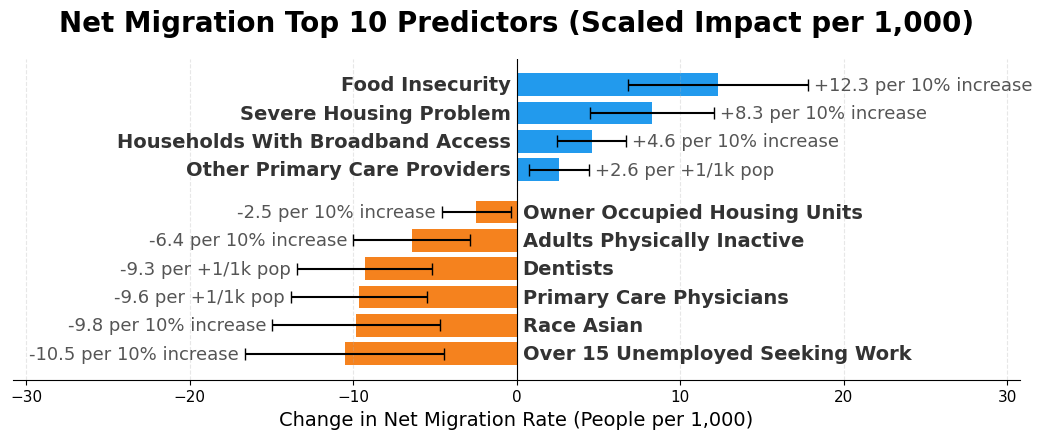

In [79]:
plot2_single_migration_model(net_ols_model, height_factor=0.45)

### Out Migration Rate

In [80]:
targets = ['Net_Migration_Rate', 'In_Migration_Rate', 'Out_Migration_Rate']

results = {}

target = targets[2]

print(f"\n{'='*40}")
print(f"ANALYZING TARGET: {target}")
print(f"{'='*40}")

# 3. Run LassoCV
lasso = LassoCV(cv=5, random_state=42, n_jobs=-1).fit(X_scaled, y[target])

# Extract selected features
coef_df = pd.DataFrame({'Feature': X.columns, 'Coef': lasso.coef_})
selected_feats = coef_df[coef_df['Coef'] != 0]['Feature'].tolist()

print(f"Lasso Selected {len(selected_feats)} features.")

if len(selected_feats) > 0:
    # 4. Run Final OLS on Selected Features
    X_selected = sm.add_constant(df_imputed[selected_feats])
    out_ols_model = sm.OLS(y[target], X_selected).fit()
    
    # Save and Print Summary
    results[target] = out_ols_model
    print(out_ols_model.summary()) # if you prefer printed output
else:
    print("Lasso dropped all variables. No OLS run.")

# out_ols_model.summary() # if you prefer the normal output


ANALYZING TARGET: Out_Migration_Rate
Lasso Selected 33 features.
                            OLS Regression Results                            
Dep. Variable:     Out_Migration_Rate   R-squared:                       0.244
Model:                            OLS   Adj. R-squared:                  0.236
Method:                 Least Squares   F-statistic:                     29.82
Date:                Wed, 19 Aug 2026   Prob (F-statistic):          9.95e-159
Time:                        02:54:45   Log-Likelihood:                -14232.
No. Observations:                3080   AIC:                         2.853e+04
Df Residuals:                    3046   BIC:                         2.874e+04
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                                                                    coef    std err          t      P>|t|      [0.025      0.975]
--------------

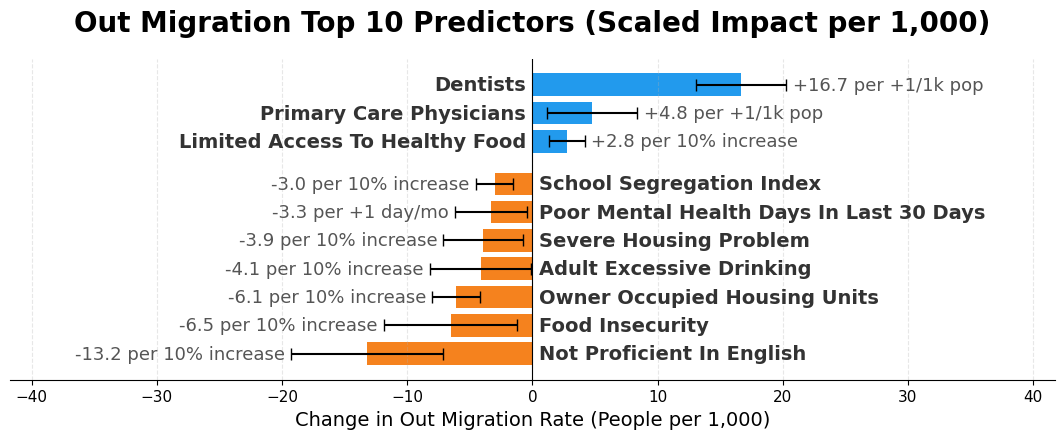

In [81]:
plot2_single_migration_model(out_ols_model, height_factor=0.45)

### In Migration Rate

In [82]:
targets = ['Net_Migration_Rate', 'In_Migration_Rate', 'Out_Migration_Rate']

results = {}

target = targets[1]

print(f"\n{'='*40}")
print(f"ANALYZING TARGET: {target}")
print(f"{'='*40}")

# 3. Run LassoCV
lasso = LassoCV(cv=5, random_state=42, n_jobs=-1).fit(X_scaled, y[target])

# Extract selected features
coef_df = pd.DataFrame({'Feature': X.columns, 'Coef': lasso.coef_})
selected_feats = coef_df[coef_df['Coef'] != 0]['Feature'].tolist()

print(f"Lasso Selected {len(selected_feats)} features.")

if len(selected_feats) > 0:
    # 4. Run Final OLS on Selected Features
    X_selected = sm.add_constant(df_imputed[selected_feats])
    in_ols_model = sm.OLS(y[target], X_selected).fit()
    
    # Save and Print Summary
    results[target] = in_ols_model
    print(in_ols_model.summary())  # if you prefer printed output
else:
    print("Lasso dropped all variables. No OLS run.")
    
# in_ols_model.summary() # if you prefer the normal output


ANALYZING TARGET: In_Migration_Rate
Lasso Selected 38 features.
                            OLS Regression Results                            
Dep. Variable:      In_Migration_Rate   R-squared:                       0.448
Model:                            OLS   Adj. R-squared:                  0.441
Method:                 Least Squares   F-statistic:                     64.87
Date:                Wed, 19 Aug 2026   Prob (F-statistic):               0.00
Time:                        02:54:46   Log-Likelihood:                -13697.
No. Observations:                3080   AIC:                         2.747e+04
Df Residuals:                    3041   BIC:                         2.771e+04
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                                                                    coef    std err          t      P>|t|      [0.025      0.975]
---------------

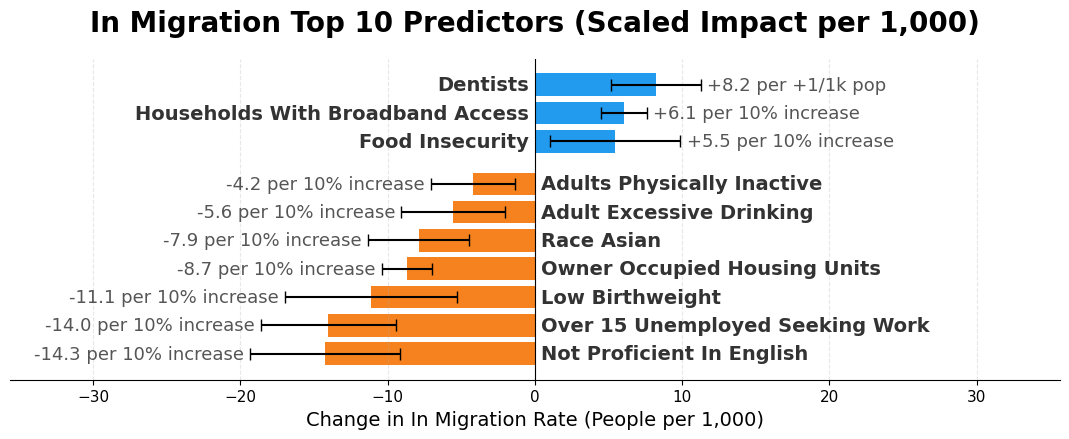

In [83]:
plot2_single_migration_model(in_ols_model, height_factor=0.45)

# Conclusion
See project slidedoc.

In [84]:
print(f"Execution count: {get_ipython().execution_count}")

Execution count: 85


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=fba226e9-ff4f-4eec-8dfc-4f877d29c8c6' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>